# Forest loss per year × Ethnologue polygon — FIXED version

Mirrors the corrections in [`forestloss_ethnologue_fixed.ipynb`](forestloss_ethnologue_fixed.ipynb), but produces a **per-year breakdown** of forest loss instead of a cumulative total.

**1. Latitude-aware pixel area.** The mosaic is in EPSG:4326 at `res=(0.01°, 0.01°)`. Each cell is ~1 km×1 km only near the equator and shrinks toward the poles. We multiply by the actual cell area in km² (spherical-Earth approximation), not by a flat `0.01`.

**2. Fraction-preserving aggregation.** Hansen `lossyear` is a categorical band (`0` = no loss, `1`–`24` = year 2001–2024). We can't average year codes, so for **each year** we first mask the native 100 m tiles to `(lossyear == y)` (binary), then merge those binary masks at 1 km with `Resampling.average` — giving the *fraction* of native sub-pixels lost in year `y` per coarse cell. Multiplying by the latitude-aware cell area gives km² of loss in that year. Mirrors the `loss`-band logic in `_fixed.ipynb` exactly, just per year.

**Output:** wide CSV with one column per year (`treeloss_y2001_km2` … `treeloss_y2024_km2`).

**Cost:** 24 merge operations (one per year). Slower than the cumulative `_fixed` notebook, but each merge is on the same set of input tiles.

In [2]:
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterstats import zonal_stats

import matplotlib.pyplot as plt
from rasterio.plot import show

In [3]:
base_path     = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")
poscol_path   = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"
yearloss_path = base_path / "maps" / "raw" / "Hansen_forest" / "yearloss"

ethnologue = gpd.read_file(poscol_path)
ethnologue = ethnologue[["ID", "geometry"]]
print(f"Number of features: {len(ethnologue)}")

Number of features: 7087


In [4]:
# --- Helpers (mirroring forestloss_ethnologue_fixed.ipynb) ----------------
def pixel_area_km2_grid(transform, shape):
    """(rows, cols) array of per-cell area in km² for an EPSG:4326 transform.
    Spherical-Earth approximation: cell area at latitude φ is
        (R * dλ * cosφ) * (R * dφ),  dλ, dφ in radians.
    """
    rows, cols = shape
    R_km  = 6371.0088
    dlat  = abs(transform.e)
    dlon  = abs(transform.a)
    lat_top = transform.f
    lat_centers = lat_top + (np.arange(rows) + 0.5) * transform.e
    lat_rad = np.deg2rad(lat_centers)
    dy_km = R_km * np.deg2rad(dlat)
    dx_km = R_km * np.cos(lat_rad) * np.deg2rad(dlon)
    area_row = (dx_km * dy_km).astype(np.float32)
    return np.broadcast_to(area_row[:, None], (rows, cols)).astype(np.float32)

def zonal_sum_on_array(array, transform, crs, polygons):
    """Write a float32 array to an in-memory GeoTIFF and zonal-sum it over `polygons`."""
    with MemoryFile() as mf:
        with mf.open(
            driver="GTiff",
            height=array.shape[0],
            width=array.shape[1],
            count=1,
            dtype="float32",
            transform=transform,
            crs=crs,
            nodata=np.float32(-9999.0),
        ) as dst:
            arr = np.where(np.isnan(array), np.float32(-9999.0), array).astype(np.float32)
            dst.write(arr, 1)
        stats = zonal_stats(polygons, mf.name, stats=["sum"], geojson_out=True)
    return [s["properties"]["sum"] for s in stats]

def mosaic_year_fraction_1km(files, year):
    """For a given `year` code (1..24), build per-tile binary masks `(lossyear == year)`,
    then merge them at ~1 km with Resampling.average. The output cell value is the
    *fraction* of native sub-pixels in that cell that had loss in `year`.
    """
    memfiles = []   # keep MemoryFile handles alive during merge
    datasets = []
    try:
        for fp in files:
            with rasterio.open(fp) as src:
                data = src.read(1)
                profile = src.profile.copy()
            mask = (data == year).astype(np.float32)
            profile.update(dtype="float32", count=1, nodata=None, compress="lzw")
            mf = MemoryFile()
            ds = mf.open(**profile)
            ds.write(mask, 1)
            memfiles.append(mf)
            datasets.append(ds)
        mos, trans = merge(datasets, res=(0.01, 0.01), resampling=Resampling.average)
        crs = datasets[0].crs
    finally:
        for ds in datasets:
            ds.close()
        for mf in memfiles:
            mf.close()
    return mos[0].astype(np.float32), trans, crs

In [5]:
# List native-resolution lossyear tiles (sorted for stable ordering)
files = sorted(glob(str(yearloss_path / "*.tif")))
print(f"Found {len(files)} raster files")

# Reproject Ethnologue polygons to match raster CRS
with rasterio.open(files[0]) as src0:
    raster_crs = src0.crs
ethnologue = ethnologue.to_crs(raster_crs)
print("Raster CRS:", raster_crs)

Found 21 raster files
Raster CRS: EPSG:4326


In [6]:
# Build the area grid once on the first year (every per-year mosaic shares the
# same bounds & transform because they come from the same set of tiles).
frac_y1, trans, crs = mosaic_year_fraction_1km(files, year=1)
print("Mosaic shape:", frac_y1.shape, "| crs:", crs)

area_km2 = pixel_area_km2_grid(trans, frac_y1.shape)
print("area_km2 range:", float(area_km2.min()), "-", float(area_km2.max()),
      "| mean:", float(area_km2.mean()))

Mosaic shape: (17000, 36000) | crs: EPSG:4326
area_km2 range: 0.10786150395870209 - 1.2364345788955688 | mean: 0.8302695155143738


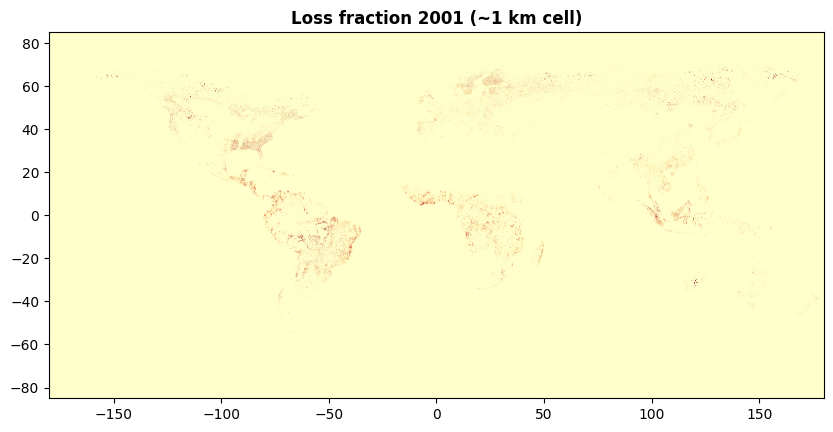

In [7]:
# Quick visual sanity check on year-1 (= 2001) loss fraction
fig, ax = plt.subplots(figsize=(10, 5))
show(frac_y1, transform=trans, ax=ax, title="Loss fraction 2001 (~1 km cell)", cmap="YlOrRd", vmin=0, vmax=0.05)
plt.show()

In [8]:
# --- Loop over years 1..24 (= 2001..2024) and zonal-sum km² of loss --------
year_results = {}

# Year 1 already computed
weighted = (frac_y1 * area_km2).astype(np.float32)
year_results[2001] = zonal_sum_on_array(weighted, trans, crs, ethnologue)
del weighted, frac_y1
print("Done year 2001")

for y in range(2, 25):
    frac_y, trans_y, crs_y = mosaic_year_fraction_1km(files, year=y)
    assert trans_y == trans and crs_y == crs and frac_y.shape == area_km2.shape, \
        f"Inconsistent mosaic geometry for year {y}"
    weighted = (frac_y * area_km2).astype(np.float32)
    year_results[2000 + y] = zonal_sum_on_array(weighted, trans, crs, ethnologue)
    del frac_y, weighted
    print(f"Done year {2000 + y}")

Done year 2001
Done year 2002
Done year 2003
Done year 2004
Done year 2005
Done year 2006
Done year 2007
Done year 2008
Done year 2009
Done year 2010
Done year 2011
Done year 2012
Done year 2013
Done year 2014
Done year 2015
Done year 2016
Done year 2017
Done year 2018
Done year 2019
Done year 2020
Done year 2021
Done year 2022
Done year 2023
Done year 2024


In [9]:
# Build wide dataframe: ID + treeloss_y2001_km2 ... treeloss_y2024_km2
df_ethnologue = pd.DataFrame({"ID": ethnologue["ID"].values})
for year in sorted(year_results):
    df_ethnologue[f"treeloss_y{year}_km2"] = year_results[year]

year_cols = [c for c in df_ethnologue.columns if c.startswith("treeloss_y")]
df_ethnologue["treeloss_total_km2"] = df_ethnologue[year_cols].sum(axis=1)

print(len(df_ethnologue))
df_ethnologue[["ID", "treeloss_total_km2"] + year_cols[:5]].head()

7087


,ID,treeloss_total_km2,treeloss_y2001_km2,treeloss_y2002_km2,treeloss_y2003_km2,treeloss_y2004_km2,treeloss_y2005_km2
0,RUS-RUS,5.906663e+05,14785.060547,15275.734375,20013.330078,28080.667969,16144.814453
1,ENG-USA,5.984556e+05,25062.070312,24394.556641,19064.494141,28576.457031,25891.636719
2,POR-BRA,1.015015e+06,39631.105469,45003.601562,41894.875000,47706.535156,42644.875000
3,ENG-AUS,1.375767e+05,5316.005371,2975.160645,7548.736816,2980.482422,3493.729248
4,CMN-CHN,6.214465e+04,1571.661499,1577.673218,1539.596069,2765.585938,1825.272949


In [10]:
# Sanity: compare the total to the cumulative `treeloss_km2` from
# `forestloss_ethnologue_fixed.ipynb`. They should match closely
# (small differences possible due to averaging order).
fixed_csv = base_path / "maps" / "raw" / "Hansen_forest" / "ethnologue_treecoverloss_fixed.csv"
if fixed_csv.exists():
    df_fixed = pd.read_csv(fixed_csv)
    cmp = df_ethnologue[["ID", "treeloss_total_km2"]].merge(df_fixed[["ID", "treeloss_km2"]], on="ID", how="left")
    cmp["diff"] = cmp["treeloss_total_km2"] - cmp["treeloss_km2"]
    print(cmp[["treeloss_total_km2", "treeloss_km2", "diff"]].describe())
else:
    print("Fixed cumulative CSV not found — skipping comparison.")

       treeloss_total_km2   treeloss_km2           diff
count        7.087000e+03    7056.000000    7056.000000
mean         1.031833e+03     529.664638     506.701424
std          1.679593e+04   10115.399814    7064.245935
min          0.000000e+00       0.000000    -314.764894
25%          3.672175e+00       0.000000       3.541378
50%          2.544351e+01       0.000000      21.671593
75%          1.736157e+02      26.889092     123.034968
max          1.015015e+06  574434.562500  440580.544922


In [11]:
out_path = yearloss_path / "ethnologue_treeloss_byyear_fixed.csv"
df_ethnologue.to_csv(out_path, index=False)
print("Exported", out_path)

Exported C:\Users\juami\Dropbox\RAships\2-Folklore-Nathan-Project\EA-Maps-Nathan-project\Measures_work\maps\raw\Hansen_forest\yearloss\ethnologue_treeloss_byyear_fixed.csv
